In [1]:
# pip install glob2
from PIL import Image
import glob

all_images = []
all_labels = []
img_size = (96, 96)
for f in glob.glob('c:\\data\\foods\\**\\*.jpg', recursive=True):
    arr = f.split('\\')
    img = Image.open(f)
    img_resize = img.resize((img_size[0], img_size[1]))
    all_images.append(img_resize)
    label = 0
    if arr[4] == 'Chicken':
        label = 0
    elif arr[4] == 'Dolsot':
        label = 1
    elif arr[4] == 'Jeyug':
        label = 2
    elif arr[4] == 'Kimchi':
        label = 3
    elif arr[4] == 'Samgyeob':
        label = 4
    elif arr[4] == 'Soybean':
        label = 5
    all_labels.append(label)

In [2]:
###############################
import numpy as np

X = np.empty((1, img_size[0], img_size[1], 3))
for img in all_images:
    X = np.vstack((X, np.array(img).reshape(1, img_size[0], img_size[1], 3)))

X.shape

(239, 96, 96, 3)

In [3]:
###############################
X = np.delete(X, (0), axis=0)

In [4]:
###############################
X.shape

(238, 96, 96, 3)

In [5]:
###############################
y = np.array(all_labels)
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

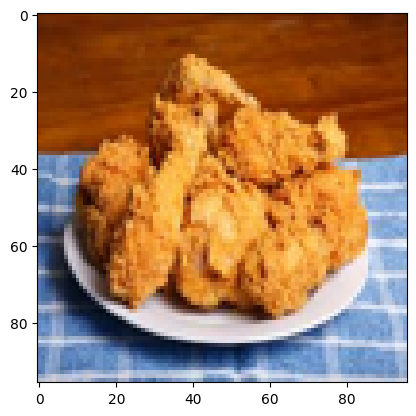

In [6]:
###############################
import matplotlib.pyplot as plt

plt.imshow(all_images[0])
plt.show()

In [7]:
###############################
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((190, 96, 96, 3), (48, 96, 96, 3), (190,), (48,))

In [8]:
###############################
import pandas as pd

pd.DataFrame(y_train).value_counts()

0
0    40
1    32
3    32
5    32
2    30
4    24
Name: count, dtype: int64

In [9]:
###############################
X_train = X_train.reshape(-1, img_size[0] * img_size[1] * 3)
X_test = X_test.reshape(-1, img_size[0] * img_size[1] * 3)

In [10]:
###############################
X_train = X_train / 255.
X_test = X_test / 255.

In [11]:
###############################
X_train = X_train.reshape(-1, img_size[0], img_size[1], 3)
X_test = X_test.reshape(-1, img_size[0], img_size[1], 3)

In [12]:
###############################
y_train[:10]

array([3, 5, 1, 4, 3, 1, 4, 2, 4, 3])

In [13]:
###############################
from tensorflow.keras import utils

y_train_backup = y_train
y_test_backup = y_test
y_train = utils.to_categorical(y_train, 6)
y_test = utils.to_categorical(y_test, 6)

In [14]:
###############################
y_train[:5]

array([[0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0.]])

In [15]:
###############################
from tensorflow.keras.applications.vgg19 import VGG19
import tensorflow as tf
# VGG19 모델
# 1. 전이학습
base_model = VGG19(
    weights="imagenet",
    input_shape=(96, 96, 3),
    include_top=False,
)
model = VGG19(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
model.trainable = False
t_model = tf.keras.models.Sequential([
    model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])
t_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
t_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 3, 3, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,822 (76.64 MB)

 Trainable params: 66,438 (259.52 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [16]:
################################
# 2. Fine-Tuning 모든 레이어 학습 - 오래걸림
t_model.trainable = True
t_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
t_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 3, 3, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,822 (76.64 MB)

 Trainable params: 66,438 (259.52 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [17]:
################################
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("c:/data/models/food_vgg_best.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
hist = t_model.fit(X_train, y_train, batch_size=32, validation_split=0.2, epochs=30, callbacks=[checkpoint])

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.2249 - loss: 1.8236
Epoch 1: val_accuracy improved from None to 0.15789, saving model to c:/data/models/food_vgg_best.keras

Epoch 1: finished saving model to c:/data/models/food_vgg_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 898ms/step - accuracy: 0.2105 - loss: 1.8189 - val_accuracy: 0.1579 - val_loss: 1.7889
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.2198 - loss: 1.8074
Epoch 2: val_accuracy improved from 0.15789 to 0.18421, saving model to c:/data/models/food_vgg_best.keras

Epoch 2: finished saving model to c:/data/models/food_vgg_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 735ms/step - accuracy: 0.2500 - loss: 1.7695 - val_accuracy: 0.1842 - val_loss: 1.7594
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.2453 - loss: 1.7328
Epoch 3: val_accuracy improved from 0.18421 to 0.21053, saving model to c:/data/models/food_vgg_best.keras

Epoch 3: finished saving model to c:/data/models/food_vgg_b

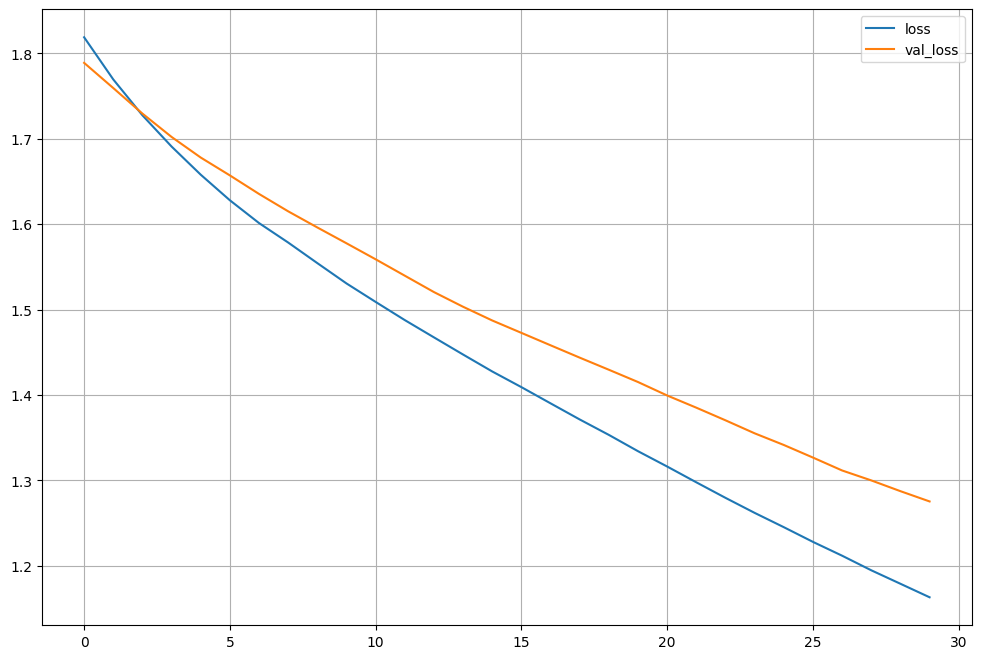

In [18]:
################################
plt.figure(figsize=(12, 8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.grid()
plt.show()

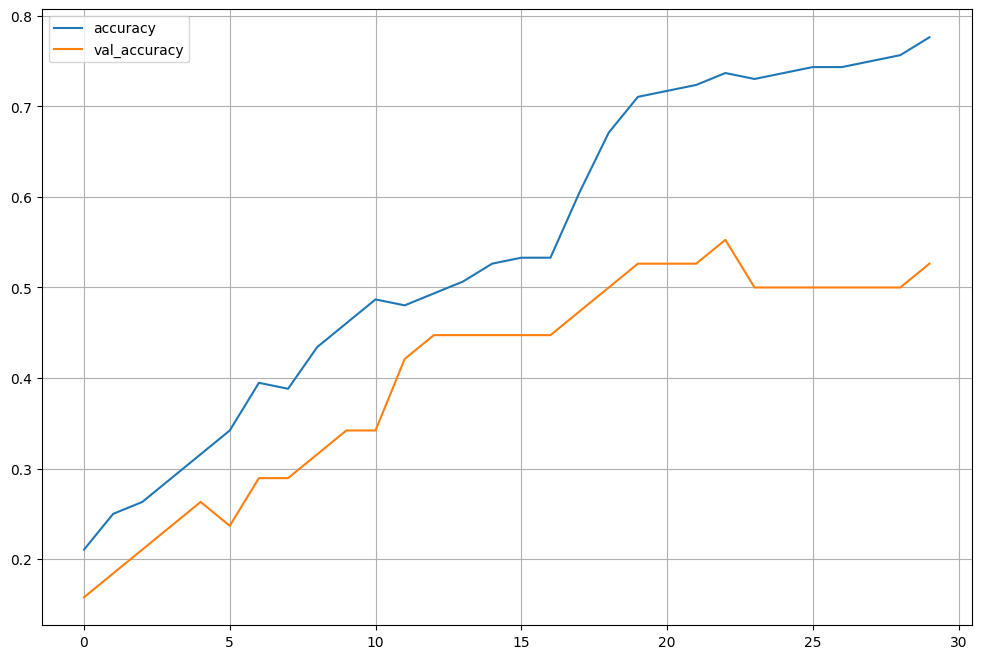

In [19]:
################################
plt.figure(figsize=(12, 8))
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.grid()
plt.show()

In [20]:
################################
from tensorflow.keras.models import load_model

model = load_model('c:/data/models/food_vgg_best.keras')
scores = model.evaluate(X_train, y_train, verbose=1)
print(scores)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))  #학습용

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 818ms/step - accuracy: 0.7000 - loss: 1.2880
[1.2880486249923706, 0.699999988079071]
compile_metrics: 70.00%


In [21]:
################################
scores = model.evaluate(X_test, y_test, verbose=1)
print(scores)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))  #검증용
# cnn 60%
# transfer learning 69%
# fine tuning 85%

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 439ms/step - accuracy: 0.5625 - loss: 1.3946
[1.3945780992507935, 0.5625]
compile_metrics: 56.25%


In [22]:
################################
pred = model.predict(X_test)
#print(pred)
print(np.argmax(pred, axis=1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
[3 1 2 2 3 0 1 3 3 5 5 3 1 3 0 2 0 1 0 0 3 5 0 1 5 0 1 1 3 5 1 4 3 1 5 4 4
 2 3 2 1 4 0 0 0 5 0 0]


In [23]:
################################
from sklearn.metrics import classification_report

print(classification_report(y_test_backup, np.argmax(pred, axis=1)))

              precision    recall  f1-score   support

           0       0.33      0.40      0.36        10
           1       0.70      0.88      0.78         8
           2       0.60      0.38      0.46         8
           3       0.50      0.62      0.56         8
           4       0.50      0.33      0.40         6
           5       0.86      0.75      0.80         8

    accuracy                           0.56        48
   macro avg       0.58      0.56      0.56        48
weighted avg       0.57      0.56      0.56        48

